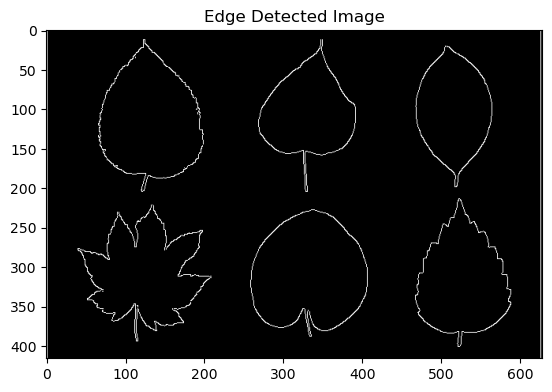

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread('imagens_teste/folhas.png', cv2.IMREAD_GRAYSCALE)

# Apply Canny edge detection to find the boundary
edges = cv2.Canny(image, 100, 200)

# Display the edge-detected image
plt.imshow(edges, cmap='gray')
plt.title('Edge Detected Image')
plt.show()


In [12]:
import networkx as nx
from itertools import combinations

def create_fully_connected_boundary_graph(edges):
    boundary_points = np.column_stack(np.where(edges > 0))
    G = nx.Graph()
    for (idx1, (x1, y1)), (idx2, (x2, y2)) in combinations(enumerate(boundary_points), 2):
        weight = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
        G.add_edge(idx1, idx2, weight=weight)
    return G, boundary_points

graph, boundary_points = create_fully_connected_boundary_graph(edges)

# Create a position dictionary for all nodes
pos = {i: (y, -x) for i, (x, y) in enumerate(boundary_points)}

# Verify that all nodes in the graph have positions
missing_positions = [node for node in graph.nodes if node not in pos]
if missing_positions:
    print(f"Warning: Missing positions for nodes: {missing_positions}")

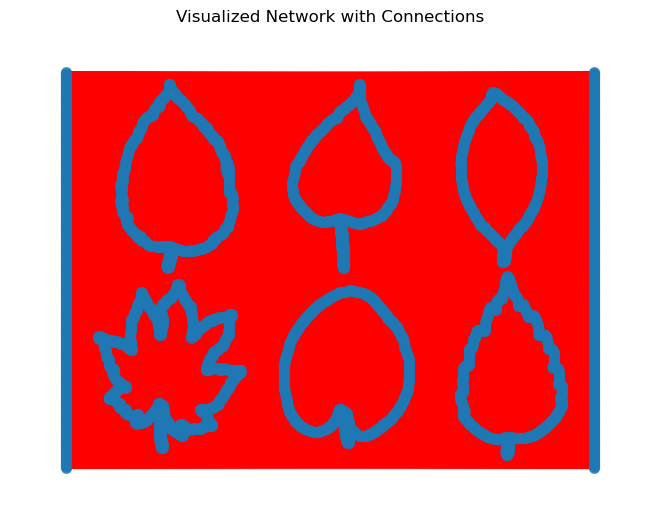

In [13]:
# Draw the graph with node positions and edges
nx.draw(graph, pos, node_size=50, with_labels=False, edge_color='red', alpha=0.6)
plt.title('Visualized Network with Connections')
plt.show()

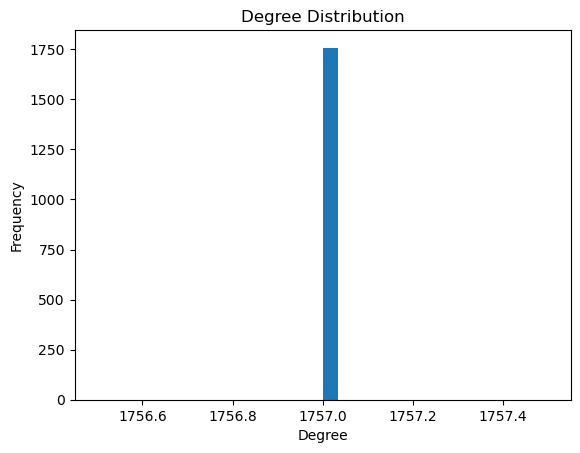

In [ ]:
# Degree distribution
degree_dict = dict(graph.degree())
degrees = list(degree_dict.values())

plt.hist(degrees, bins=30)
plt.title('Degree Distribution')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.show()


In [ ]:
# Clustering coefficient
clustering_coeff = nx.clustering(graph)
avg_clustering = np.mean(list(clustering_coeff.values()))

print(f"Average Clustering Coefficient: {avg_clustering}")


Average Clustering Coefficient: 1.0


In [ ]:
# Shortest path lengths
shortest_path_lengths = dict(nx.all_pairs_shortest_path_length(graph))

# Compute the average shortest path length
total_length = sum(sum(lengths.values()) for lengths in shortest_path_lengths.values())
num_paths = sum(len(lengths) for lengths in shortest_path_lengths.values())
avg_shortest_path_length = total_length / num_paths

print(f"Average Shortest Path Length: {avg_shortest_path_length}")


Average Shortest Path Length: 0.9994311717861206


In [ ]:
# Random graph for comparison
random_graph = nx.erdos_renyi_graph(len(graph.nodes), 0.1)

# Compare average shortest path length
avg_shortest_path_length_random = nx.average_shortest_path_length(random_graph)
avg_clustering_random = nx.average_clustering(random_graph)

print(f"Average Shortest Path Length (Random Graph): {avg_shortest_path_length_random}")
print(f"Average Clustering Coefficient (Random Graph): {avg_clustering_random}")


Average Shortest Path Length (Random Graph): 1.899613637114147
Average Clustering Coefficient (Random Graph): 0.10035723033956001


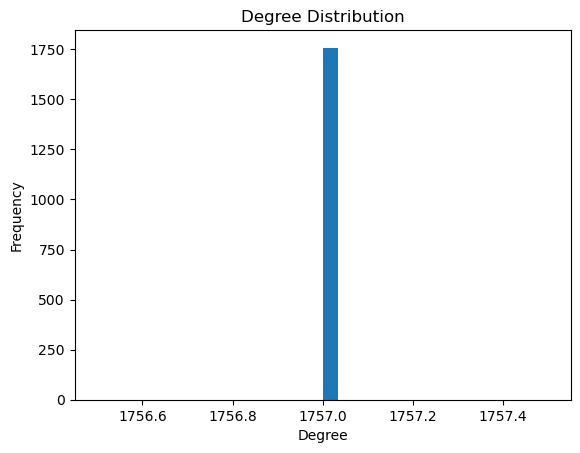

Average Clustering Coefficient: 1.0
Average Shortest Path Length: 0.9994311717861206
Average Shortest Path Length (Random Graph): 1.9003032239642115
Average Clustering Coefficient (Random Graph): 0.09960071891573925


In [ ]:
import cv2
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

# Load image and detect edges
image = cv2.imread('imagens_teste/folha-low.jpg', cv2.IMREAD_GRAYSCALE)
edges = cv2.Canny(image, 100, 200)

# Create fully connected graph
graph, boundary_points = create_fully_connected_boundary_graph(edges)

# Analyze degree distribution
degree_dict = dict(graph.degree())
degrees = list(degree_dict.values())
plt.hist(degrees, bins=30)
plt.title('Degree Distribution')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.show()

# Clustering coefficient
clustering_coeff = nx.clustering(graph)
avg_clustering = np.mean(list(clustering_coeff.values()))
print(f"Average Clustering Coefficient: {avg_clustering}")

# Shortest path length
shortest_path_lengths = dict(nx.all_pairs_shortest_path_length(graph))
total_length = sum(sum(lengths.values()) for lengths in shortest_path_lengths.values())
num_paths = sum(len(lengths) for lengths in shortest_path_lengths.values())
avg_shortest_path_length = total_length / num_paths
print(f"Average Shortest Path Length: {avg_shortest_path_length}")

# Comparison with random graph
random_graph = nx.erdos_renyi_graph(len(graph.nodes), 0.1)
avg_shortest_path_length_random = nx.average_shortest_path_length(random_graph)
avg_clustering_random = nx.average_clustering(random_graph)
print(f"Average Shortest Path Length (Random Graph): {avg_shortest_path_length_random}")
print(f"Average Clustering Coefficient (Random Graph): {avg_clustering_random}")


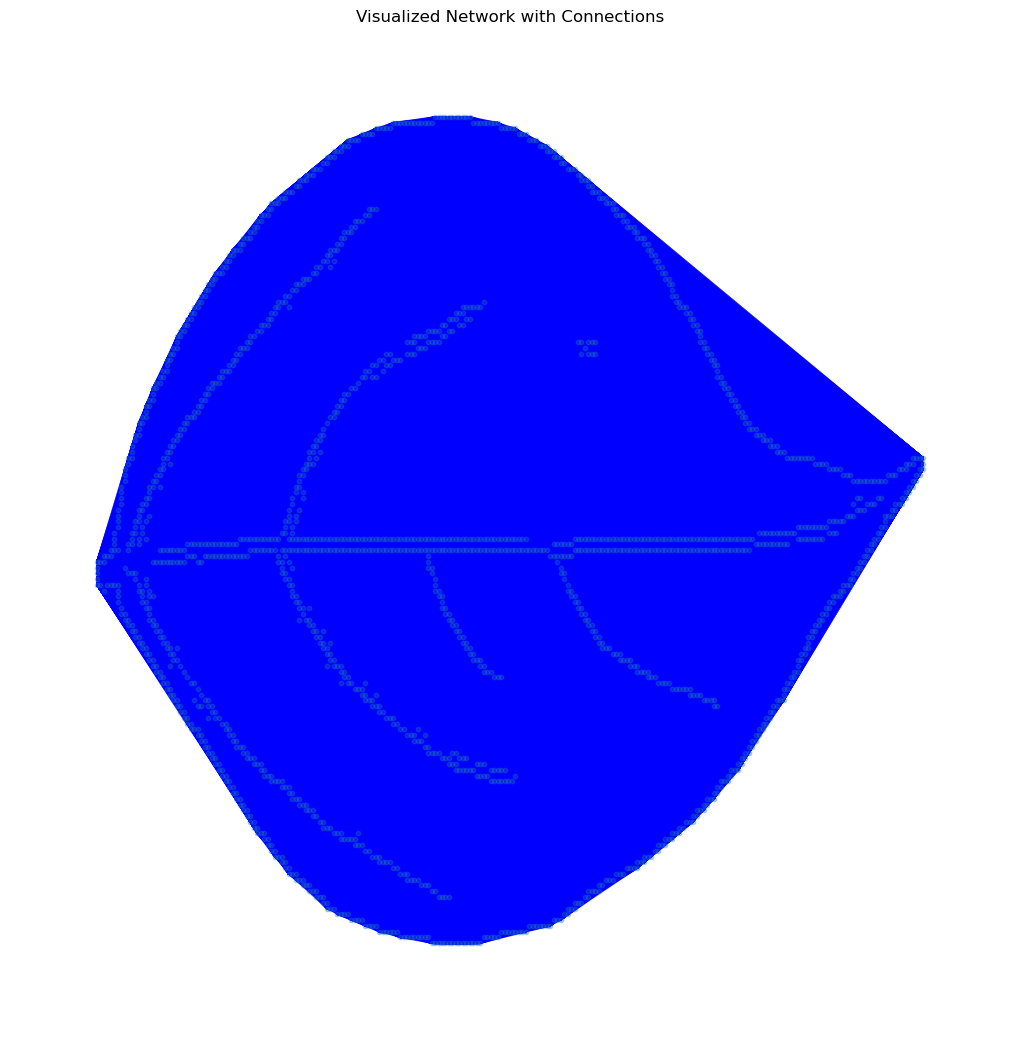

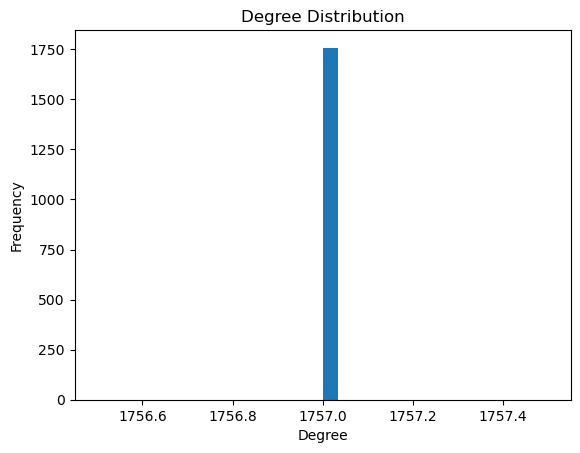

Average Clustering Coefficient: 1.0
Average Shortest Path Length: 0.9994311717861206
Average Shortest Path Length (Random Graph): 1.900272791492894
Average Clustering Coefficient (Random Graph): 0.0996258106155966


In [ ]:
import cv2
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

# Load image and detect edges
image = cv2.imread('imagens_teste/folha-low.jpg', cv2.IMREAD_GRAYSCALE)
edges = cv2.Canny(image, 100, 200)

# Create fully connected graph
def create_fully_connected_boundary_graph(edges):
    boundary_points = np.column_stack(np.where(edges > 0))
    G = nx.Graph()
    for (idx1, (x1, y1)), (idx2, (x2, y2)) in combinations(enumerate(boundary_points), 2):
        weight = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
        G.add_edge(idx1, idx2, weight=weight)
    return G, boundary_points

graph, boundary_points = create_fully_connected_boundary_graph(edges)

# Visualize the resulting network with connections
plt.figure(figsize=(10, 10))
pos = {i: (y, -x) for i, (x, y) in enumerate(boundary_points)}  # Adjust positions for display

# Draw the graph with node positions and edges
nx.draw(graph, pos, node_size=10, with_labels=False, edge_color='blue', alpha=0.3)
plt.title('Visualized Network with Connections')
plt.show()

# Analyze degree distribution
degree_dict = dict(graph.degree())
degrees = list(degree_dict.values())
plt.hist(degrees, bins=30)
plt.title('Degree Distribution')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.show()

# Clustering coefficient
clustering_coeff = nx.clustering(graph)
avg_clustering = np.mean(list(clustering_coeff.values()))
print(f"Average Clustering Coefficient: {avg_clustering}")

# Shortest path length
shortest_path_lengths = dict(nx.all_pairs_shortest_path_length(graph))
total_length = sum(sum(lengths.values()) for lengths in shortest_path_lengths.values())
num_paths = sum(len(lengths) for lengths in shortest_path_lengths.values())
avg_shortest_path_length = total_length / num_paths
print(f"Average Shortest Path Length: {avg_shortest_path_length}")

# Comparison with random graph
random_graph = nx.erdos_renyi_graph(len(graph.nodes), 0.1)
avg_shortest_path_length_random = nx.average_shortest_path_length(random_graph)
avg_clustering_random = nx.average_clustering(random_graph)
print(f"Average Shortest Path Length (Random Graph): {avg_shortest_path_length_random}")
print(f"Average Clustering Coefficient (Random Graph): {avg_clustering_random}")


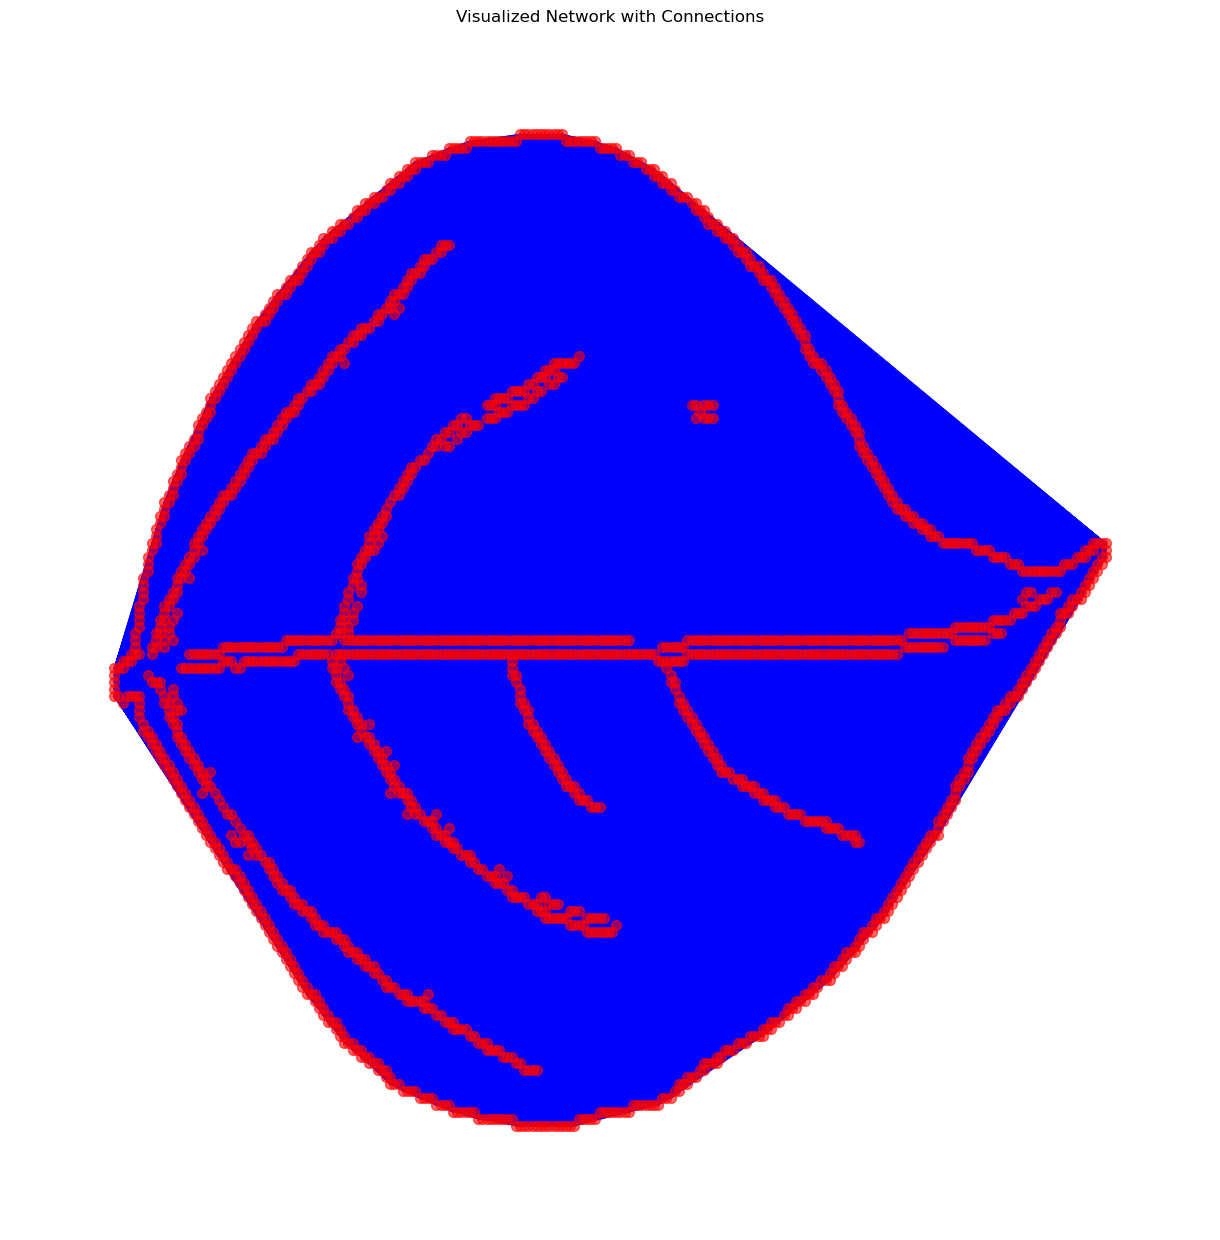

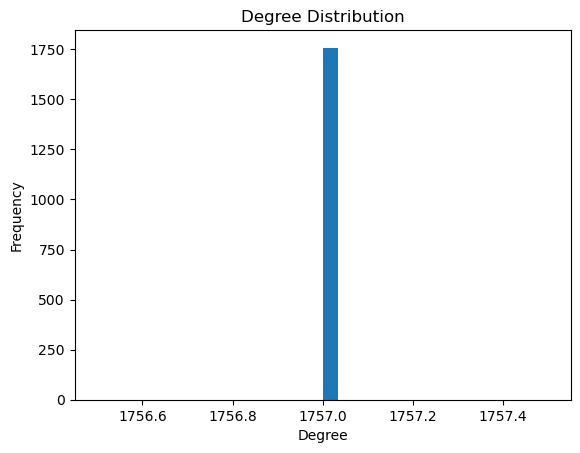

Average Clustering Coefficient: 1.0
Average Shortest Path Length: 0.9994311717861206
Average Shortest Path Length (Random Graph): 1.8997146470189452
Average Clustering Coefficient (Random Graph): 0.10038660929816129

C. N. Degree (node degree):
Node 0: Degree 1757
Node 1: Degree 1757
Node 2: Degree 1757
Node 3: Degree 1757
Node 4: Degree 1757
Node 5: Degree 1757
Node 6: Degree 1757
Node 7: Degree 1757
Node 8: Degree 1757
Node 9: Degree 1757
Node 10: Degree 1757
Node 11: Degree 1757
Node 12: Degree 1757
Node 13: Degree 1757
Node 14: Degree 1757
Node 15: Degree 1757
Node 16: Degree 1757
Node 17: Degree 1757
Node 18: Degree 1757
Node 19: Degree 1757
Node 20: Degree 1757
Node 21: Degree 1757
Node 22: Degree 1757
Node 23: Degree 1757
Node 24: Degree 1757
Node 25: Degree 1757
Node 26: Degree 1757
Node 27: Degree 1757
Node 28: Degree 1757
Node 29: Degree 1757
Node 30: Degree 1757
Node 31: Degree 1757
Node 32: Degree 1757
Node 33: Degree 1757
Node 34: Degree 1757
Node 35: Degree 1757
Node 36: 

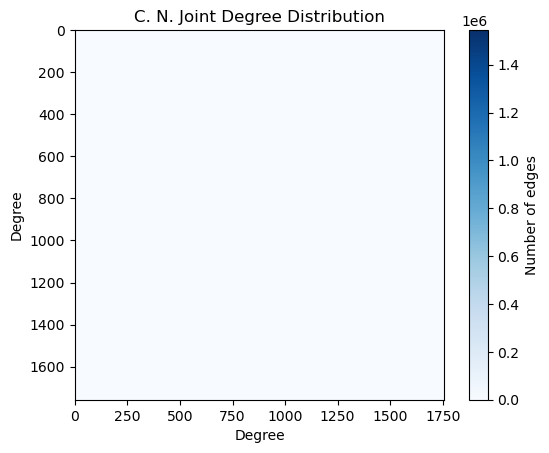

In [1]:
import cv2
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from collections import defaultdict

# Load image and detect edges
image = cv2.imread('imagens_teste/folha-low.jpg', cv2.IMREAD_GRAYSCALE)
edges = cv2.Canny(image, 100, 200)

# Create fully connected graph
def create_fully_connected_boundary_graph(edges):
    boundary_points = np.column_stack(np.where(edges > 0))
    G = nx.Graph()
    for (idx1, (x1, y1)), (idx2, (x2, y2)) in combinations(enumerate(boundary_points), 2):
        weight = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
        G.add_edge(idx1, idx2, weight=weight)
    return G, boundary_points

graph, boundary_points = create_fully_connected_boundary_graph(edges)

# Visualize the resulting network with connections
plt.figure(figsize=(12, 12))
pos = {i: (y, -x) for i, (x, y) in enumerate(boundary_points)}  # Adjust positions for display

# Draw the graph with larger nodes and thicker edges for better visibility
nx.draw(graph, pos, node_size=50, node_color='red', edge_color='blue', width=0.5, with_labels=False, alpha=0.6)
plt.title('Visualized Network with Connections')
plt.show()

# Analyze degree distribution
degree_dict = dict(graph.degree())
degrees = list(degree_dict.values())
plt.hist(degrees, bins=30)
plt.title('Degree Distribution')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.show()

# Clustering coefficient
clustering_coeff = nx.clustering(graph)
avg_clustering = np.mean(list(clustering_coeff.values()))
print(f"Average Clustering Coefficient: {avg_clustering}")

# Shortest path length
shortest_path_lengths = dict(nx.all_pairs_shortest_path_length(graph))
total_length = sum(sum(lengths.values()) for lengths in shortest_path_lengths.values())
num_paths = sum(len(lengths) for lengths in shortest_path_lengths.values())
avg_shortest_path_length = total_length / num_paths
print(f"Average Shortest Path Length: {avg_shortest_path_length}")

# Comparison with random graph
random_graph = nx.erdos_renyi_graph(len(graph.nodes), 0.1)
avg_shortest_path_length_random = nx.average_shortest_path_length(random_graph)
avg_clustering_random = nx.average_clustering(random_graph)
print(f"Average Shortest Path Length (Random Graph): {avg_shortest_path_length_random}")
print(f"Average Clustering Coefficient (Random Graph): {avg_clustering_random}")

# Calculate C. N. Degree (degree of each node)
print("\nC. N. Degree (node degree):")
for node, degree in degree_dict.items():
    print(f"Node {node}: Degree {degree}")

# Calculate C. N. Joint Degree (joint degree distribution)
joint_degree = defaultdict(int)

for u, v in graph.edges():
    deg_u = degree_dict[u]
    deg_v = degree_dict[v]
    joint_degree[(deg_u, deg_v)] += 1

print("\nC. N. Joint Degree (joint degree distribution):")
for (deg_u, deg_v), count in joint_degree.items():
    print(f"Degree {deg_u} - Degree {deg_v}: {count} edges")

# Visualizing joint degree as a matrix
max_degree = max(degree_dict.values())
joint_degree_matrix = np.zeros((max_degree + 1, max_degree + 1))

# Fill the matrix
for (deg_u, deg_v), count in joint_degree.items():
    joint_degree_matrix[deg_u][deg_v] = count
    joint_degree_matrix[deg_v][deg_u] = count  # Symmetric since the graph is undirected

plt.imshow(joint_degree_matrix, cmap='Blues', interpolation='none')
plt.colorbar(label="Number of edges")
plt.title('C. N. Joint Degree Distribution')
plt.xlabel('Degree')
plt.ylabel('Degree')
plt.show()


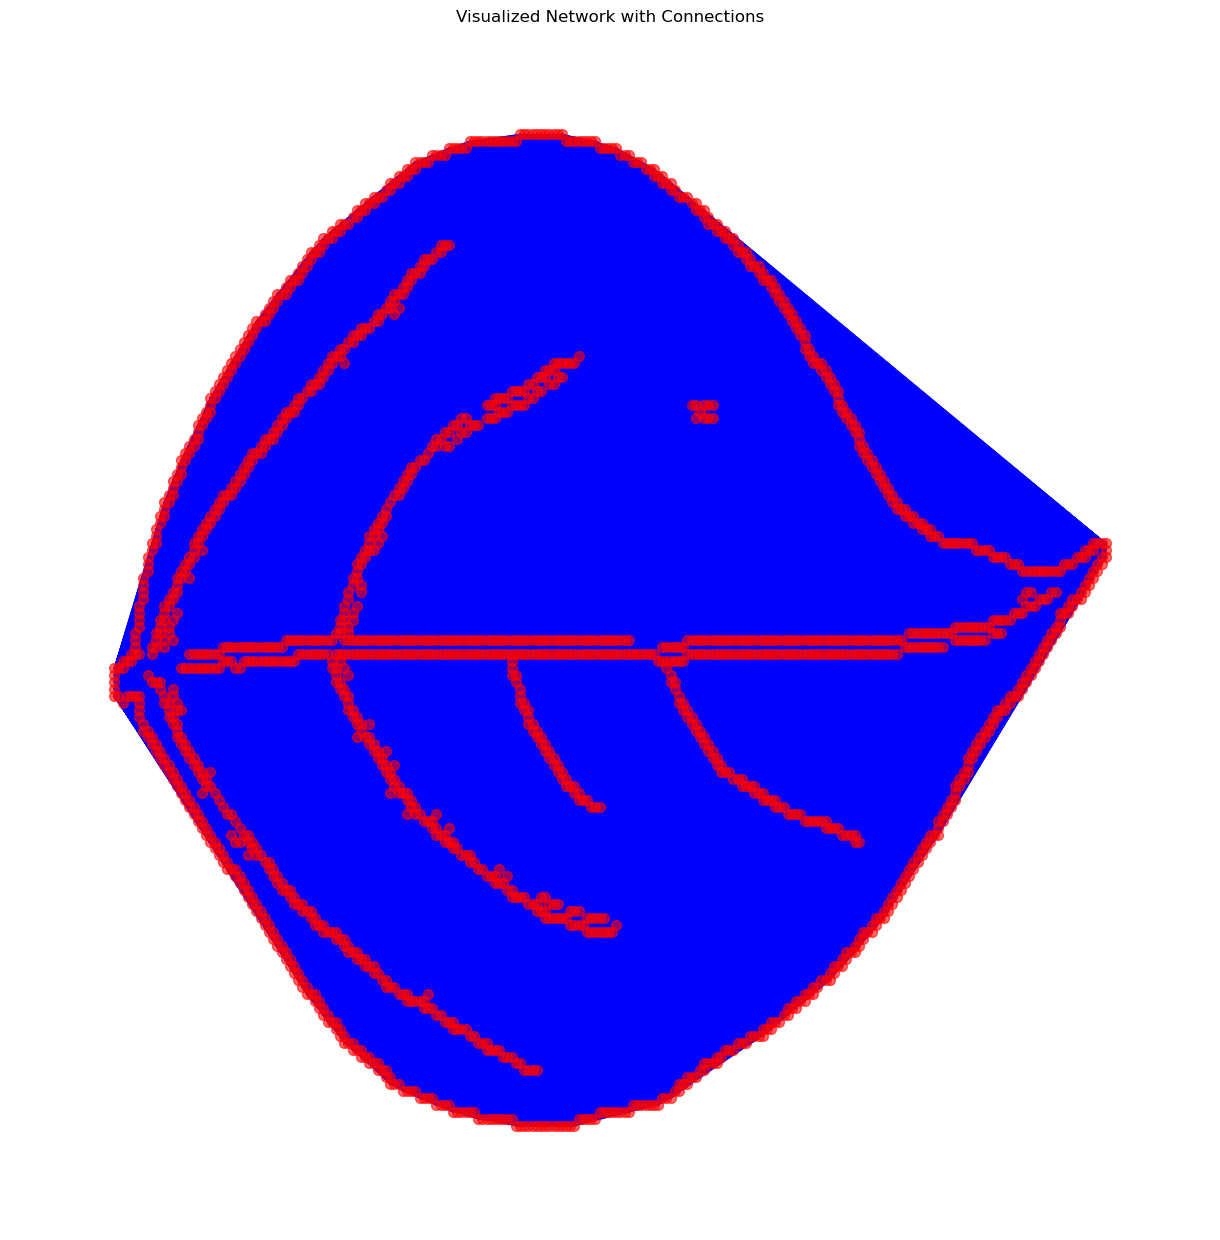

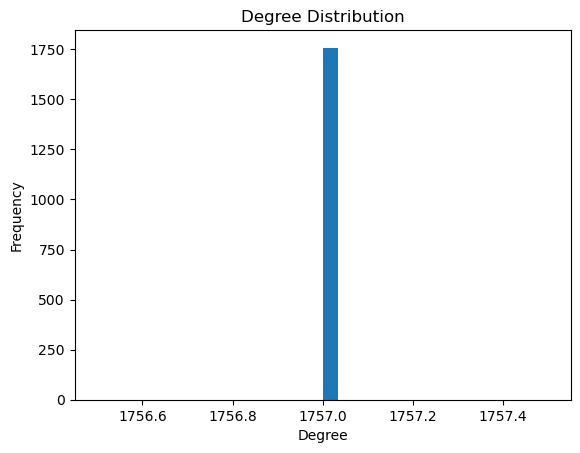

Average Clustering Coefficient: 1.0
Average Shortest Path Length: 0.9994311717861206
Average Geodesic Path Length: 1.0
Average Shortest Path Length (Random Graph): 1.8999794742693454
Average Clustering Coefficient (Random Graph): 0.09998373323548847

C. N. Degree (node degree):
Node 0: Degree 1757
Node 1: Degree 1757
Node 2: Degree 1757
Node 3: Degree 1757
Node 4: Degree 1757
Node 5: Degree 1757
Node 6: Degree 1757
Node 7: Degree 1757
Node 8: Degree 1757
Node 9: Degree 1757
Node 10: Degree 1757
Node 11: Degree 1757
Node 12: Degree 1757
Node 13: Degree 1757
Node 14: Degree 1757
Node 15: Degree 1757
Node 16: Degree 1757
Node 17: Degree 1757
Node 18: Degree 1757
Node 19: Degree 1757
Node 20: Degree 1757
Node 21: Degree 1757
Node 22: Degree 1757
Node 23: Degree 1757
Node 24: Degree 1757
Node 25: Degree 1757
Node 26: Degree 1757
Node 27: Degree 1757
Node 28: Degree 1757
Node 29: Degree 1757
Node 30: Degree 1757
Node 31: Degree 1757
Node 32: Degree 1757
Node 33: Degree 1757
Node 34: Degree 1

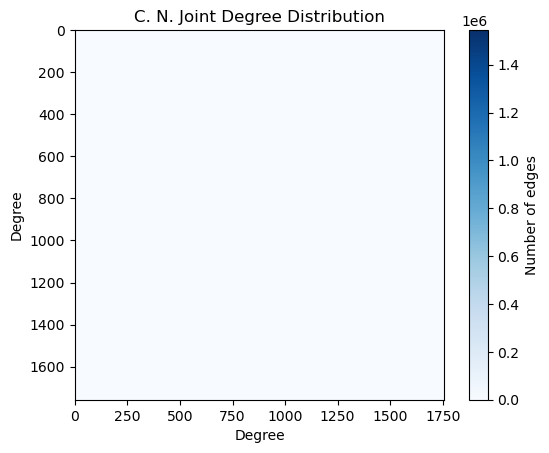

In [2]:
import cv2
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from collections import defaultdict

# Load image and detect edges
image = cv2.imread('imagens_teste/folha-low.jpg', cv2.IMREAD_GRAYSCALE)
edges = cv2.Canny(image, 100, 200)

# Create fully connected graph
def create_fully_connected_boundary_graph(edges):
    boundary_points = np.column_stack(np.where(edges > 0))
    G = nx.Graph()
    for (idx1, (x1, y1)), (idx2, (x2, y2)) in combinations(enumerate(boundary_points), 2):
        weight = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
        G.add_edge(idx1, idx2, weight=weight)
    return G, boundary_points

graph, boundary_points = create_fully_connected_boundary_graph(edges)

# Visualize the resulting network with connections
plt.figure(figsize=(12, 12))
pos = {i: (y, -x) for i, (x, y) in enumerate(boundary_points)}  # Adjust positions for display

# Draw the graph with larger nodes and thicker edges for better visibility
nx.draw(graph, pos, node_size=50, node_color='red', edge_color='blue', width=0.5, with_labels=False, alpha=0.6)
plt.title('Visualized Network with Connections')
plt.show()

# Analyze degree distribution
degree_dict = dict(graph.degree())
degrees = list(degree_dict.values())
plt.hist(degrees, bins=30)
plt.title('Degree Distribution')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.show()

# Clustering coefficient
clustering_coeff = nx.clustering(graph)
avg_clustering = np.mean(list(clustering_coeff.values()))
print(f"Average Clustering Coefficient: {avg_clustering}")

# Shortest path length
shortest_path_lengths = dict(nx.all_pairs_shortest_path_length(graph))
total_length = sum(sum(lengths.values()) for lengths in shortest_path_lengths.values())
num_paths = sum(len(lengths) for lengths in shortest_path_lengths.values())
avg_shortest_path_length = total_length / num_paths
print(f"Average Shortest Path Length: {avg_shortest_path_length}")

# Calculate the Average Geodesic Path Length
if nx.is_connected(graph):
    avg_geodesic_path_length = nx.average_shortest_path_length(graph)
    print(f"Average Geodesic Path Length: {avg_geodesic_path_length}")
else:
    print("Graph is not connected, cannot compute average geodesic path length.")

# Comparison with random graph
random_graph = nx.erdos_renyi_graph(len(graph.nodes), 0.1)
avg_shortest_path_length_random = nx.average_shortest_path_length(random_graph)
avg_clustering_random = nx.average_clustering(random_graph)
print(f"Average Shortest Path Length (Random Graph): {avg_shortest_path_length_random}")
print(f"Average Clustering Coefficient (Random Graph): {avg_clustering_random}")

# Calculate C. N. Degree (degree of each node)
print("\nC. N. Degree (node degree):")
for node, degree in degree_dict.items():
    print(f"Node {node}: Degree {degree}")

# Calculate C. N. Joint Degree (joint degree distribution)
joint_degree = defaultdict(int)

for u, v in graph.edges():
    deg_u = degree_dict[u]
    deg_v = degree_dict[v]
    joint_degree[(deg_u, deg_v)] += 1

print("\nC. N. Joint Degree (joint degree distribution):")
for (deg_u, deg_v), count in joint_degree.items():
    print(f"Degree {deg_u} - Degree {deg_v}: {count} edges")

# Visualizing joint degree as a matrix
max_degree = max(degree_dict.values())
joint_degree_matrix = np.zeros((max_degree + 1, max_degree + 1))

# Fill the matrix
for (deg_u, deg_v), count in joint_degree.items():
    joint_degree_matrix[deg_u][deg_v] = count
    joint_degree_matrix[deg_v][deg_u] = count  # Symmetric since the graph is undirected

plt.imshow(joint_degree_matrix, cmap='Blues', interpolation='none')
plt.colorbar(label="Number of edges")
plt.title('C. N. Joint Degree Distribution')
plt.xlabel('Degree')
plt.ylabel('Degree')
plt.show()


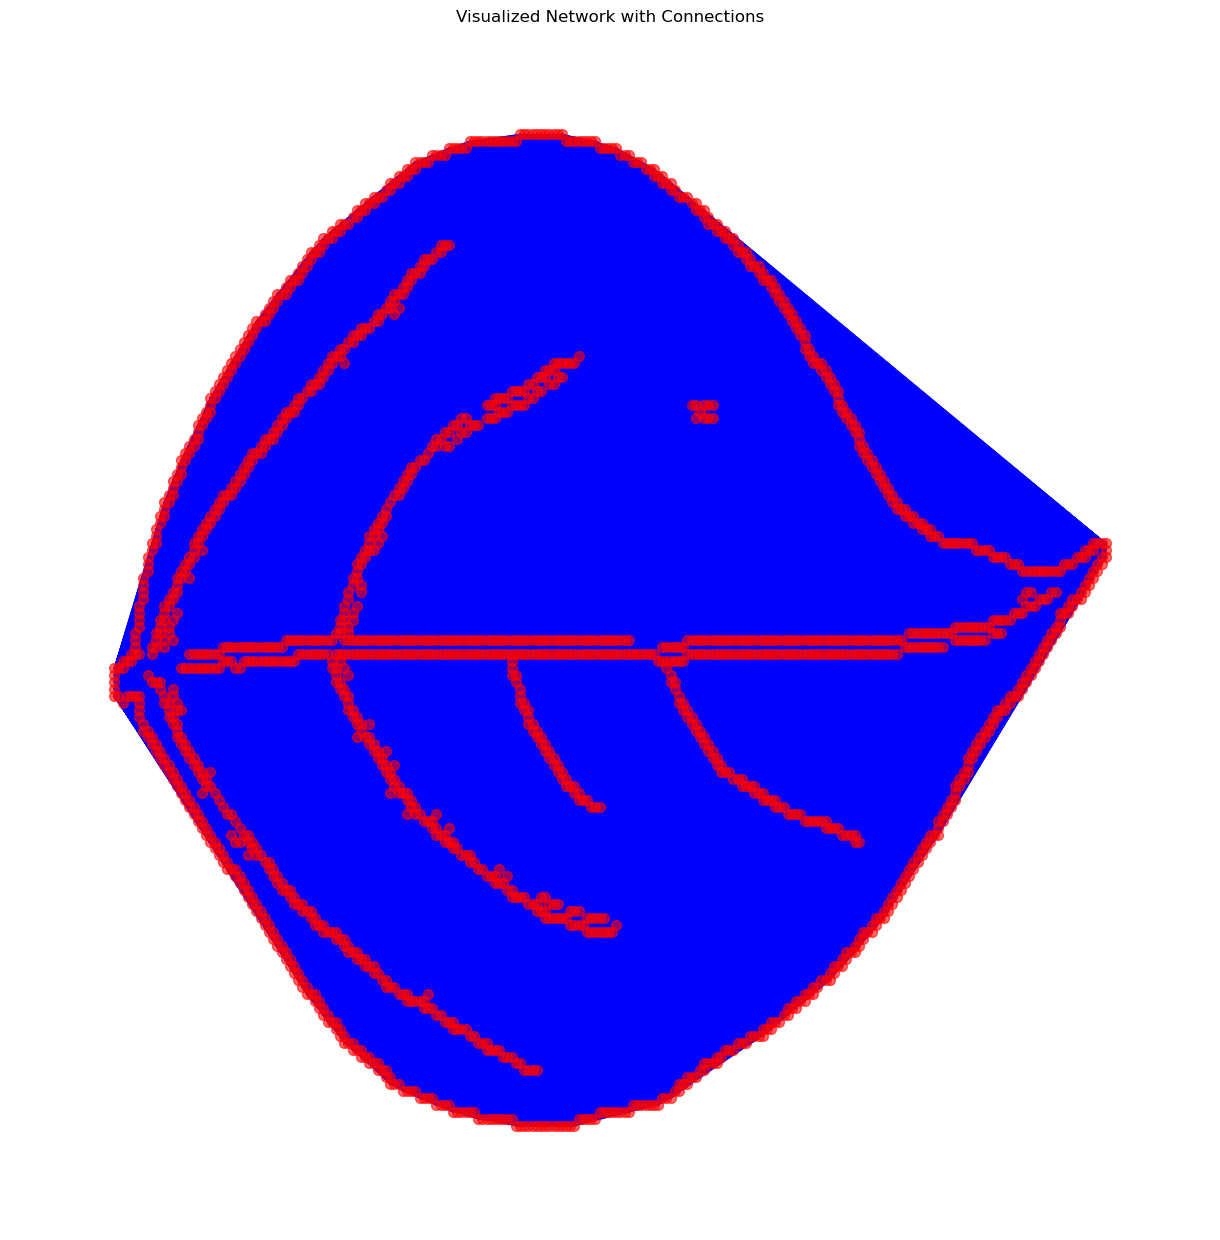

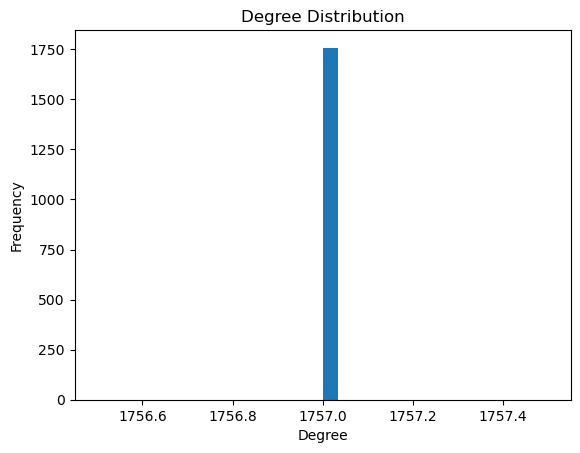

Average Clustering Coefficient: 1.0
Average Shortest Path Length: 0.9994311717861206
Average Geodesic Path Length: 1.0
Normalized Geodesic Path Length: 1.0

Normalized Degree (node degree):
Node 0: Normalized Degree 1.0000
Node 1: Normalized Degree 1.0000
Node 2: Normalized Degree 1.0000
Node 3: Normalized Degree 1.0000
Node 4: Normalized Degree 1.0000
Node 5: Normalized Degree 1.0000
Node 6: Normalized Degree 1.0000
Node 7: Normalized Degree 1.0000
Node 8: Normalized Degree 1.0000
Node 9: Normalized Degree 1.0000
Node 10: Normalized Degree 1.0000
Node 11: Normalized Degree 1.0000
Node 12: Normalized Degree 1.0000
Node 13: Normalized Degree 1.0000
Node 14: Normalized Degree 1.0000
Node 15: Normalized Degree 1.0000
Node 16: Normalized Degree 1.0000
Node 17: Normalized Degree 1.0000
Node 18: Normalized Degree 1.0000
Node 19: Normalized Degree 1.0000
Node 20: Normalized Degree 1.0000
Node 21: Normalized Degree 1.0000
Node 22: Normalized Degree 1.0000
Node 23: Normalized Degree 1.0000
Node

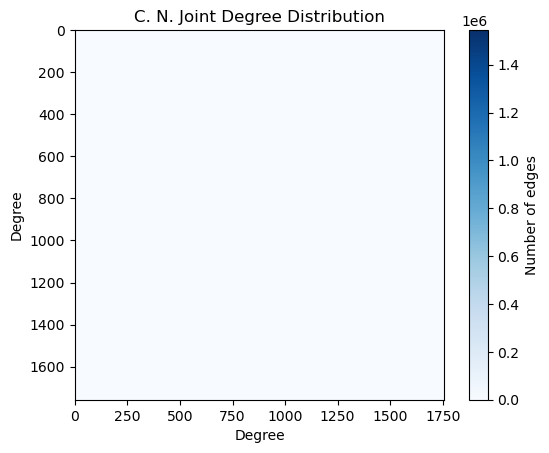

In [3]:
import cv2
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from collections import defaultdict

# Load image and detect edges
image = cv2.imread('imagens_teste/folha-low.jpg', cv2.IMREAD_GRAYSCALE)
edges = cv2.Canny(image, 100, 200)

# Create fully connected graph
def create_fully_connected_boundary_graph(edges):
    boundary_points = np.column_stack(np.where(edges > 0))
    G = nx.Graph()
    for (idx1, (x1, y1)), (idx2, (x2, y2)) in combinations(enumerate(boundary_points), 2):
        weight = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
        G.add_edge(idx1, idx2, weight=weight)
    return G, boundary_points

graph, boundary_points = create_fully_connected_boundary_graph(edges)

# Visualize the resulting network with connections
plt.figure(figsize=(12, 12))
pos = {i: (y, -x) for i, (x, y) in enumerate(boundary_points)}  # Adjust positions for display

# Draw the graph with larger nodes and thicker edges for better visibility
nx.draw(graph, pos, node_size=50, node_color='red', edge_color='blue', width=0.5, with_labels=False, alpha=0.6)
plt.title('Visualized Network with Connections')
plt.show()

# Analyze degree distribution
degree_dict = dict(graph.degree())
degrees = list(degree_dict.values())
plt.hist(degrees, bins=30)
plt.title('Degree Distribution')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.show()

# Clustering coefficient
clustering_coeff = nx.clustering(graph)
avg_clustering = np.mean(list(clustering_coeff.values()))
print(f"Average Clustering Coefficient: {avg_clustering}")

# Shortest path length
shortest_path_lengths = dict(nx.all_pairs_shortest_path_length(graph))
total_length = sum(sum(lengths.values()) for lengths in shortest_path_lengths.values())
num_paths = sum(len(lengths) for lengths in shortest_path_lengths.values())
avg_shortest_path_length = total_length / num_paths
print(f"Average Shortest Path Length: {avg_shortest_path_length}")

# Calculate the Average Geodesic Path Length
if nx.is_connected(graph):
    avg_geodesic_path_length = nx.average_shortest_path_length(graph)
    diameter = nx.diameter(graph)  # Longest shortest path
    normalized_geodesic_path_length = avg_geodesic_path_length / diameter
    print(f"Average Geodesic Path Length: {avg_geodesic_path_length}")
    print(f"Normalized Geodesic Path Length: {normalized_geodesic_path_length}")
else:
    print("Graph is not connected, cannot compute average geodesic path length.")

# Normalize the degree
n = len(graph.nodes)  # Total number of nodes
max_degree = n - 1  # Maximum possible degree in a fully connected graph
normalized_degree = {node: degree / max_degree for node, degree in degree_dict.items()}

print("\nNormalized Degree (node degree):")
for node, norm_deg in normalized_degree.items():
    print(f"Node {node}: Normalized Degree {norm_deg:.4f}")

# Comparison with random graph
random_graph = nx.erdos_renyi_graph(len(graph.nodes), 0.1)
avg_shortest_path_length_random = nx.average_shortest_path_length(random_graph)
avg_clustering_random = nx.average_clustering(random_graph)
print(f"Average Shortest Path Length (Random Graph): {avg_shortest_path_length_random}")
print(f"Average Clustering Coefficient (Random Graph): {avg_clustering_random}")

# Calculate C. N. Joint Degree (joint degree distribution)
joint_degree = defaultdict(int)

for u, v in graph.edges():
    deg_u = degree_dict[u]
    deg_v = degree_dict[v]
    joint_degree[(deg_u, deg_v)] += 1

print("\nC. N. Joint Degree (joint degree distribution):")
for (deg_u, deg_v), count in joint_degree.items():
    print(f"Degree {deg_u} - Degree {deg_v}: {count} edges")

# Visualizing joint degree as a matrix
joint_degree_matrix = np.zeros((max_degree + 1, max_degree + 1))

# Fill the matrix
for (deg_u, deg_v), count in joint_degree.items():
    joint_degree_matrix[deg_u][deg_v] = count
    joint_degree_matrix[deg_v][deg_u] = count  # Symmetric since the graph is undirected

plt.imshow(joint_degree_matrix, cmap='Blues', interpolation='none')
plt.colorbar(label="Number of edges")
plt.title('C. N. Joint Degree Distribution')
plt.xlabel('Degree')
plt.ylabel('Degree')
plt.show()

